In [113]:
import joblib
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [114]:
#Data we will be using 

data = pd.read_csv('../Datasets/pre-processedData.csv')

data.drop(columns=['Unnamed: 0'], inplace=True)
data.head(5)


print(data['is_malicious'].value_counts())

is_malicious
0    77054
1    71463
Name: count, dtype: int64


### Predicting the values from the binary classifier !

In [115]:
### Binary Classifier 

X = data.drop(columns=['is_malicious', 'Severity_Score'])
y = data['is_malicious']

### Splitting the dataset into training and testing 

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

### X is all the columns except the is_malicious and severity score, whereas for now our target column is y 

In [116]:
### Testing the binary classifier model 

binary_model = joblib.load('binary_classifier.pkl')
severity_model = joblib.load('severity_model.pkl')


In [117]:
data['Severity_Score'] = data['Severity_Score'] - 1
x_test_index = X_test.index ## To get the index of the x_test from the data
y_test_severity = data.loc[x_test_index, 'Severity_Score']  ## Gives the Severity Score of the X_test 




### So here we took the X_test's index and then extracted the Severity_score of the selected X_test columns so that we have same number of samples for the severity score as well. This is done for the sole reason of getting y_test_severity for the calculation

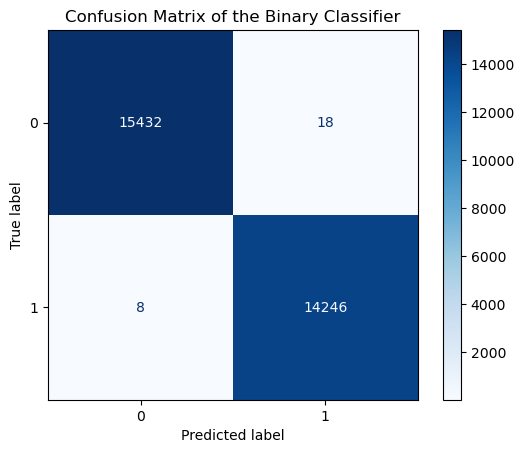

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15450
           1       1.00      1.00      1.00     14254

    accuracy                           1.00     29704
   macro avg       1.00      1.00      1.00     29704
weighted avg       1.00      1.00      1.00     29704



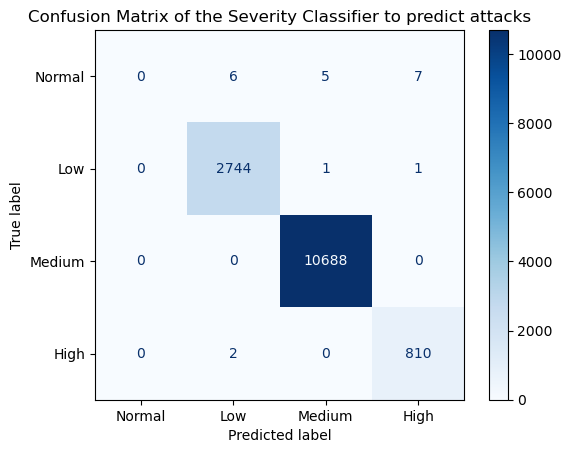

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        18
           0       1.00      1.00      1.00      2746
           1       1.00      1.00      1.00     10688
           2       0.99      1.00      0.99       812

    accuracy                           1.00     14264
   macro avg       0.75      0.75      0.75     14264
weighted avg       1.00      1.00      1.00     14264



/opt/anaconda3/envs/Network_Intrusion/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/Network_Intrusion/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/Network_Intrusion/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

In [124]:
### Cascade analysis 
def cascade_analyis(X_test,y_test, y_test_severity):
    binary_testing_pred = binary_model.predict(X_test) ## Binary prediction has been done

    severity_pred = np.full(len(X_test), -1) ## created the whole list of -1's (normal), of size X_test

    attack_mask = binary_testing_pred ==1 ## Only the attacks

    if attack_mask.any(): ### Just to prevent the model from empty array
        severity_pred[attack_mask] = severity_model.predict(X_test[attack_mask]) ## This is the severity testing prediction

    ## this will make severity_pred[attack_mask] -> -1,0,1,2 based on the attack classified
    ### Confusion Matrix for the binary classifier 

    evlauation_report = confusion_matrix(y_test, binary_testing_pred) 
    display = ConfusionMatrixDisplay(confusion_matrix=evlauation_report)
    display.plot(cmap = 'Blues')
    plt.title("Confusion Matrix of the Binary Classifier")
    plt.savefig('../Model Pictures/CascadeConfusionMatrixBinary.png')
    plt.show()


    ### Classification Report for the Binary Classifier
    
    binary_report = classification_report(y_test, binary_testing_pred )
    print(binary_report)

    ### Confusion Matrix for the severity classifier

    severity_evaluation_report = confusion_matrix(y_test_severity[attack_mask],severity_pred[attack_mask])
    display = ConfusionMatrixDisplay(confusion_matrix=severity_evaluation_report, display_labels=['Normal','Low', 'Medium', 'High'])
    display.plot(cmap = 'Blues')
    plt.title("Confusion Matrix of the Severity Classifier to predict attacks")
    
    plt.savefig('../Model Pictures/CascadeClassifierSeverity.png')
    plt.show()
    

    ## Classification report for the severity classifier 
    severity_report = classification_report(y_test_severity[attack_mask], severity_pred[attack_mask])
    print(severity_report)

cascade_analyis(X_test, y_test, y_test_severity)
